Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import readsav
from math import sqrt, pi
from astropy.table import Table
import math
from astropy.stats import sigma_clip
from matplotlib import cm
import matplotlib as mpl
from pathlib import Path

Load telemetry file

In [23]:
telem = Path("/g/lu/data/keck_telemetry/20170823/sdata902/nirc3/2017aug23/n0058_LGS_trs.sav") #c0103, c0104, c0105, c0107
data = readsav("/g/lu/data/keck_telemetry/20170823/sdata902/nirc3/2017aug23/n0058_LGS_trs.sav")
data.b

rec.array([(array([1181299960, 1181299960, 1181299960, ..., 1181300007, 1181300007,
                  1181300007], dtype=uint32), array([1225181508689513254, 1225181508689523252, 1225181508689533260, ...,
                  1225181509114723600, 1225181509114733602, 1225181509114743605],
                 dtype=uint64), array([[61., 74., 54., 66.],
                  [54., 48., 64., 59.],
                  [66., 62., 52., 67.],
                  ...,
                  [71., 55., 47., 72.],
                  [65., 60., 76., 62.],
                  [71., 58., 59., 63.]], dtype=float32), array([[-0.06547099,  0.00119432],
                  [ 0.07323071, -0.02424211],
                  [-0.03010042,  0.07898092],
                  ...,
                  [-0.00564263,  0.17000361],
                  [ 0.02708422, -0.05273234],
                  [-0.02388717,  0.06775158]], dtype=float32), array([[ 0.15893343, -0.05429252],
                  [ 0.16997914, -0.05778494],
                  [ 0.1634

In [24]:
telem = Path("/g/lu/data/keck_telemetry/20170823/sdata902/nirc3/2017aug23/n0058_LGS_trs.sav") #c0103, c0104, c0105, c0107
data = readsav(telem)
data.b

rec.array([(array([1181299960, 1181299960, 1181299960, ..., 1181300007, 1181300007,
                  1181300007], dtype=uint32), array([1225181508689513254, 1225181508689523252, 1225181508689533260, ...,
                  1225181509114723600, 1225181509114733602, 1225181509114743605],
                 dtype=uint64), array([[61., 74., 54., 66.],
                  [54., 48., 64., 59.],
                  [66., 62., 52., 67.],
                  ...,
                  [71., 55., 47., 72.],
                  [65., 60., 76., 62.],
                  [71., 58., 59., 63.]], dtype=float32), array([[-0.06547099,  0.00119432],
                  [ 0.07323071, -0.02424211],
                  [-0.03010042,  0.07898092],
                  ...,
                  [-0.00564263,  0.17000361],
                  [ 0.02708422, -0.05273234],
                  [-0.02388717,  0.06775158]], dtype=float32), array([[ 0.15893343, -0.05429252],
                  [ 0.16997914, -0.05778494],
                  [ 0.1634

In [50]:
data.header

array([b'SIMPLE  =                    T / Tape is in Fits format                         ',
       b'BITPIX  =                   32 / Bits per pixel                                 ',
       b'NAXIS   =                    2 / Number of axes                                 ',
       b'NAXIS1  =                 1024 / Number of pixels in axis 1                     ',
       b'NAXIS2  =                 1024 / Number of pixels in axis 2                     ',
       b'BSCALE  =              1.00000 / Scaling factor                                 ',
       b'BZERO   =              0.00000 / Scaling zero-point                             ',
       b"OUTDIR  = '/sdata902/nirc7/2017aug11/            ' / Original directory         ",
       b"ROOTNAME= 'n                 ' / File prefix                                    ",
       b'FRAMENO =                  103 / Frame number                                   ',
       b"FILENAME= 'n0103.fits        ' / Original File name                    

Telemetry Duration

In [51]:
start_time = data.a.timestamp[0][0] * 100 # in ns
stop_time = data.a.timestamp[0][-1] * 100 # in ns
tint = (stop_time - start_time) * 1e-9
print(f"Integration time: {tint} ns")

Integration time: 42.530045952 ns


Plot Residual RMS Wavefront

In [52]:
# Purely for plotting purposes: 
SMALL_SIZE = 10
MEDIUM_SIZE = 11
BIGGER_SIZE = 13

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

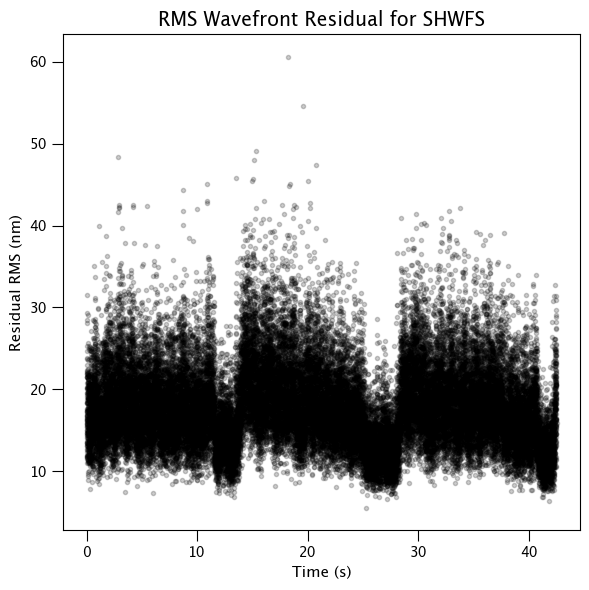

In [53]:
res = data.a.residualrms[0][0]
x = np.linspace(0, len(res)/1000, len(res))

fig, axes = plt.subplots()
plt.plot(x, data.a.residualrms[0][0], 'k.', alpha = 0.2, linewidth = 0.3)
plt.title(f"RMS Wavefront Residual for SHWFS", fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Residual RMS (nm)')
plt.tight_layout()
plt.show()

**Tip-Tilt Validation**

KAON 1165 AO Telemetry 4 PSF-R file states that the four entries for each subarray in the apdcounts data below correspond to the "four quadrants." The telemetry colab notebook states:

For each telemetry files, we get out one number for each entry by averaging over timestamps and(or) averaging over space:
- residual_rms: average over timestamps
- residual_rms_std: average over timestamps
- apd_counts & apd_counts_std: first average over space, then over timestamps

I am assuming the "averaging over space" for the apdcounts data is averaging over the four quadrants referenced in the KAON (WFS divided into four quadrants).

In [63]:
# Apdcounts for TT sensor to validate TT brightness input into MAOS
data.b.apdcounts[0]


array([[82., 50., 56., 59.],
       [71., 50., 74., 52.],
       [73., 66., 64., 35.],
       ...,
       [81., 55., 64., 54.],
       [85., 64., 64., 67.],
       [81., 45., 68., 70.]], dtype=float32)

In [56]:
data.b.timestamp[0]

array([1225171183541348156, 1225171183541358159, 1225171183541368155, ...,
       1225171183966498440, 1225171183966508447, 1225171183966518445],
      dtype=uint64)

In [57]:
# Average apdcounts over space and then over time
space_avg = np.mean(data.b.apdcounts[0], axis=1)
np.mean(space_avg)

62.01961

In [70]:
np.mean(data.b.apdcounts[0])

62.01961

Unit for this data is simply "counts." powfs.siglev for c0103 is [1270 1621 3723], where the second entry corresponds to the signal level (e.g. brightness) for STRAP, the TT WFS. 

In [59]:
data.header[-3]

b"STAPDQMN= '62070.500         ' / STRAP Quad Mean APD counts (co                 "

In [68]:
data.dtt_offset

array([ 0., -0.], dtype=float32)

APDCOUNTS versus Time for Select Frames

In [71]:
n0103 = Path("/g/lu/data/keck_telemetry/20170811/sdata902/nirc7/2017aug11/n0103_LGS_trs.sav") #c0103, c0104, c0105, c0107
n0105 = Path("/g/lu/data/keck_telemetry/20170811/sdata902/nirc7/2017aug11/n0105_LGS_trs.sav")
n0107 = Path("/g/lu/data/keck_telemetry/20170811/sdata902/nirc7/2017aug11/n0107_LGS_trs.sav")
n0103_data = readsav(n0103)
n0105_data = readsav(n0105)
n0107_data = readsav(n0107)

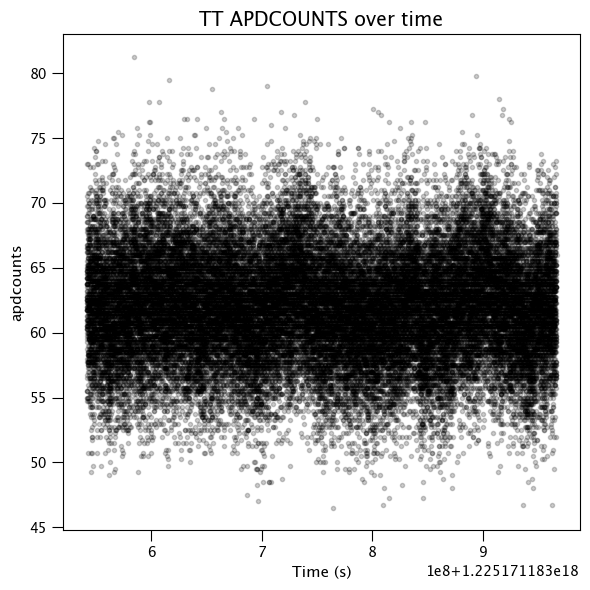

In [74]:
apdcounts_space_avg = np.mean(n0103_data.b.apdcounts[0], axis=1)
fig, axes = plt.subplots()
plt.plot(n0103_data.b.timestamp[0], apdcounts_space_avg, 'k.', alpha = 0.2, linewidth = 0.3)
plt.title(f"TT APDCOUNTS over time n0103", fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('apdcounts')
plt.tight_layout()
plt.show()

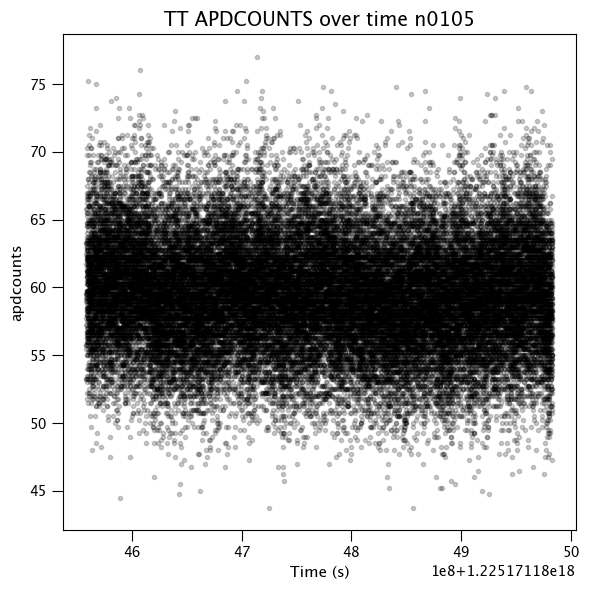

In [75]:
apdcounts_space_avg = np.mean(n0105_data.b.apdcounts[0], axis=1)
fig, axes = plt.subplots()
plt.plot(n0105_data.b.timestamp[0], apdcounts_space_avg, 'k.', alpha = 0.2, linewidth = 0.3)
plt.title(f"TT APDCOUNTS over time n0105", fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('apdcounts')
plt.tight_layout()
plt.show()

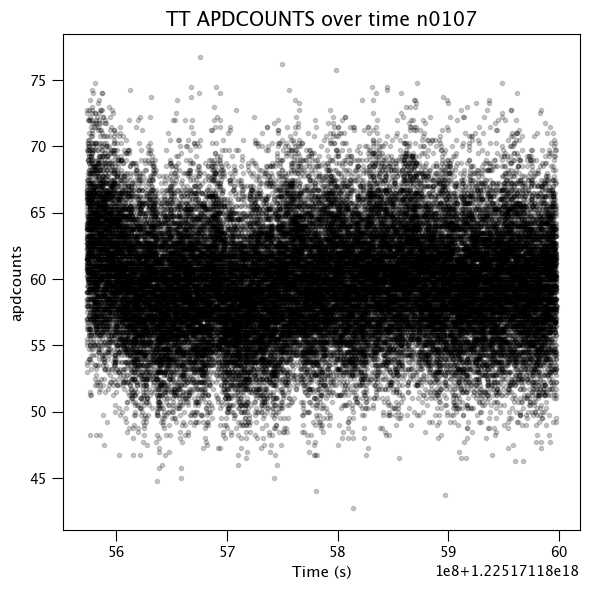

In [76]:
apdcounts_space_avg = np.mean(n0107_data.b.apdcounts[0], axis=1)
fig, axes = plt.subplots()
plt.plot(n0107_data.b.timestamp[0], apdcounts_space_avg, 'k.', alpha = 0.2, linewidth = 0.3)
plt.title(f"TT APDCOUNTS over time n0107", fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('apdcounts')
plt.tight_layout()
plt.show()